# Cleaned Combined Dataset: Data Visualization Notebook

This notebook provides **descriptive EDA only** for `data/cleaned_combined.csv`.

Scope:
- Data overview
- Data quality checks
- Univariate distributions
- Grouped and temporal views
- Correlation and feature relationships

Excluded:
- Synthetic labeling
- Anomaly scoring/model outputs

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = Path("data/cleaned_combined.csv")
TOP_K_CORR_FEATURES = 20
MAX_SCATTER_POINTS = 5000

## 1) Load Dataset and Overview

In [5]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print("\nColumn dtypes:")
print(df.dtypes.value_counts())

display(df.head(3))
display(df.tail(3))
display(df.describe(include="all").T.head(20))

Shape: 29,146 rows x 73 columns

Column dtypes:
int64      36
float64    34
object      3
Name: count, dtype: int64


,timestamp,Processor_DPC Rate,Processor_% Idle Time,Processor_% Interrupt Time,Processor_% User Time,Processor_% C1 Time,Processor_% Processor Time,Processor_C1 Transitions/sec,Processor_% DPC Time,Processor_% Privileged Time,...,Memory_Available MBytes,Memory_Modified Page List Bytes,Memory_Cache Faults/sec,Memory_Committed Bytes,Memory_System Driver Total Bytes,Memory_Pages Input/sec,Memory_Pool Paged Resident Bytes,Memory_Write Copies/sec,os,source_file
0,2019-04-01 23:12:31.353,14,74.791667,0.000000,12.324669,73.333333,24.103018,360.486597,0.078128,4.303456,...,414,33116160,0.600018,915390464,5849088,67.310683,42708992,0.0,win7,win7_normal_1.csv
1,2019-04-01 23:12:46.353,0,90.208333,0.208333,2.083333,88.009289,9.791667,216.615181,0.208333,7.708333,...,414,26374144,31.955242,926330880,5849088,1957.675542,48304128,0.0,win7,win7_normal_1.csv
2,2019-04-01 23:13:01.353,0,99.791667,0.000000,0.104167,98.920487,0.208333,67.861457,0.000000,0.104167,...,418,27045888,1.199908,924794880,5849088,0.133323,48107520,0.0,win7,win7_normal_1.csv


,timestamp,Processor_DPC Rate,Processor_% Idle Time,Processor_% Interrupt Time,Processor_% User Time,Processor_% C1 Time,Processor_% Processor Time,Processor_C1 Transitions/sec,Processor_% DPC Time,Processor_% Privileged Time,...,Memory_Available MBytes,Memory_Modified Page List Bytes,Memory_Cache Faults/sec,Memory_Committed Bytes,Memory_System Driver Total Bytes,Memory_Pages Input/sec,Memory_Pool Paged Resident Bytes,Memory_Write Copies/sec,os,source_file
29143,2019-04-04 01:06:25.445,0,99.276665,0.000000,0.000000,99.276665,0.000912,169.063916,0.000000,0.000000,...,231,9310208,1.802814,5692448768,18264064,33.852846,40910848,0.000000,win10,win10_normal_4.csv
29144,2019-04-04 01:06:35.460,50,38.531550,0.390026,8.346560,38.531550,59.827303,707.313743,1.092073,51.483456,...,146,6496256,191.206355,5733322752,18264064,16317.140951,52654080,131.797592,win10,win10_normal_4.csv
29145,2019-04-04 01:06:45.457,1,52.586921,0.547054,8.987309,52.586921,38.495546,3565.962611,2.735268,29.540894,...,226,118784,18.105903,5761806336,18264064,6823.724739,55640064,56.718492,win10,win10_normal_4.csv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,29146,29146,2019-04-04 01:06:45.457,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Processor_DPC Rate,29146.0,NaN,NaN,NaN,18.408907,30.913405,0.0,0.0,1.0,31.0,326.0
Processor_% Idle Time,29146.0,NaN,NaN,NaN,73.368537,17.51945,0.0,66.5625,74.791667,81.69231,100.0
Processor_% Interrupt Time,29146.0,NaN,NaN,NaN,0.100817,0.326591,0.0,0.0,0.0,0.104167,10.641964
Processor_% User Time,29146.0,NaN,NaN,NaN,13.414841,12.655722,0.0,1.25,12.324669,23.04638,96.354167
Processor_% C1 Time,29146.0,NaN,NaN,NaN,72.812751,17.26656,0.0,66.666667,73.333333,80.776022,100.31348
Processor_% Processor Time,29146.0,NaN,NaN,NaN,25.004665,16.600009,0.0,17.344734,24.103018,31.247757,100.0
Processor_C1 Transitions/sec,29146.0,NaN,NaN,NaN,1354.271086,1470.051376,0.0,140.492701,360.486597,2913.829928,10318.521387
Processor_% DPC Time,29146.0,NaN,NaN,NaN,0.439162,1.163089,0.0,0.0,0.078128,0.3125,21.953888
Processor_% Privileged Time,29146.0,NaN,NaN,NaN,11.574555,12.33791,0.0,1.249962,4.303456,21.979167,83.815369


## 2) Data Quality Profile

In [6]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(4)

quality_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct,
})

print(f"Duplicate rows: {df.duplicated().sum():,}")
print("\nTop columns by missing values:")
display(quality_df.head(15))

categorical_candidates = [c for c in ["os", "source_file"] if c in df.columns]
if categorical_candidates:
    for col in categorical_candidates:
        print(f"\nValue counts for {col}:")
        display(df[col].value_counts(dropna=False))

if "timestamp" in df.columns:
    ts = pd.to_datetime(df["timestamp"], errors="coerce")
    print("\nTimestamp parse success:", ts.notna().mean().round(4))
    print("Timestamp range:", ts.min(), "to", ts.max())

Duplicate rows: 0

Top columns by missing values:


,missing_count,missing_pct
timestamp,0,0.0
Processor_DPC Rate,0,0.0
Processor_% Idle Time,0,0.0
Processor_% Interrupt Time,0,0.0
Processor_% User Time,0,0.0
Processor_% C1 Time,0,0.0
Processor_% Processor Time,0,0.0
Processor_C1 Transitions/sec,0,0.0
Processor_% DPC Time,0,0.0
Processor_% Privileged Time,0,0.0



Value counts for os:


os
win10    16756
win7     12390
Name: count, dtype: int64


Value counts for source_file:


source_file
win10_normal_4.csv    8634
win7_normal_2.csv     6452
win10_normal_3.csv    5943
win7_normal_1.csv     3006
win7_normal_3.csv     2932
win10_normal_1.csv    1726
win10_normal_2.csv     453
Name: count, dtype: int64


Timestamp parse success: 1.0
Timestamp range: 2019-04-01 23:12:31.353000 to 2019-04-24 12:04:18.765000


## 3) Univariate Distributions

Numeric columns: 70
Selected metrics for univariate analysis:
- Processor_DPC Rate
- Processor_% Idle Time
- Processor_% Interrupt Time
- Processor_% User Time
- Processor_% C1 Time
- Processor_% Processor Time


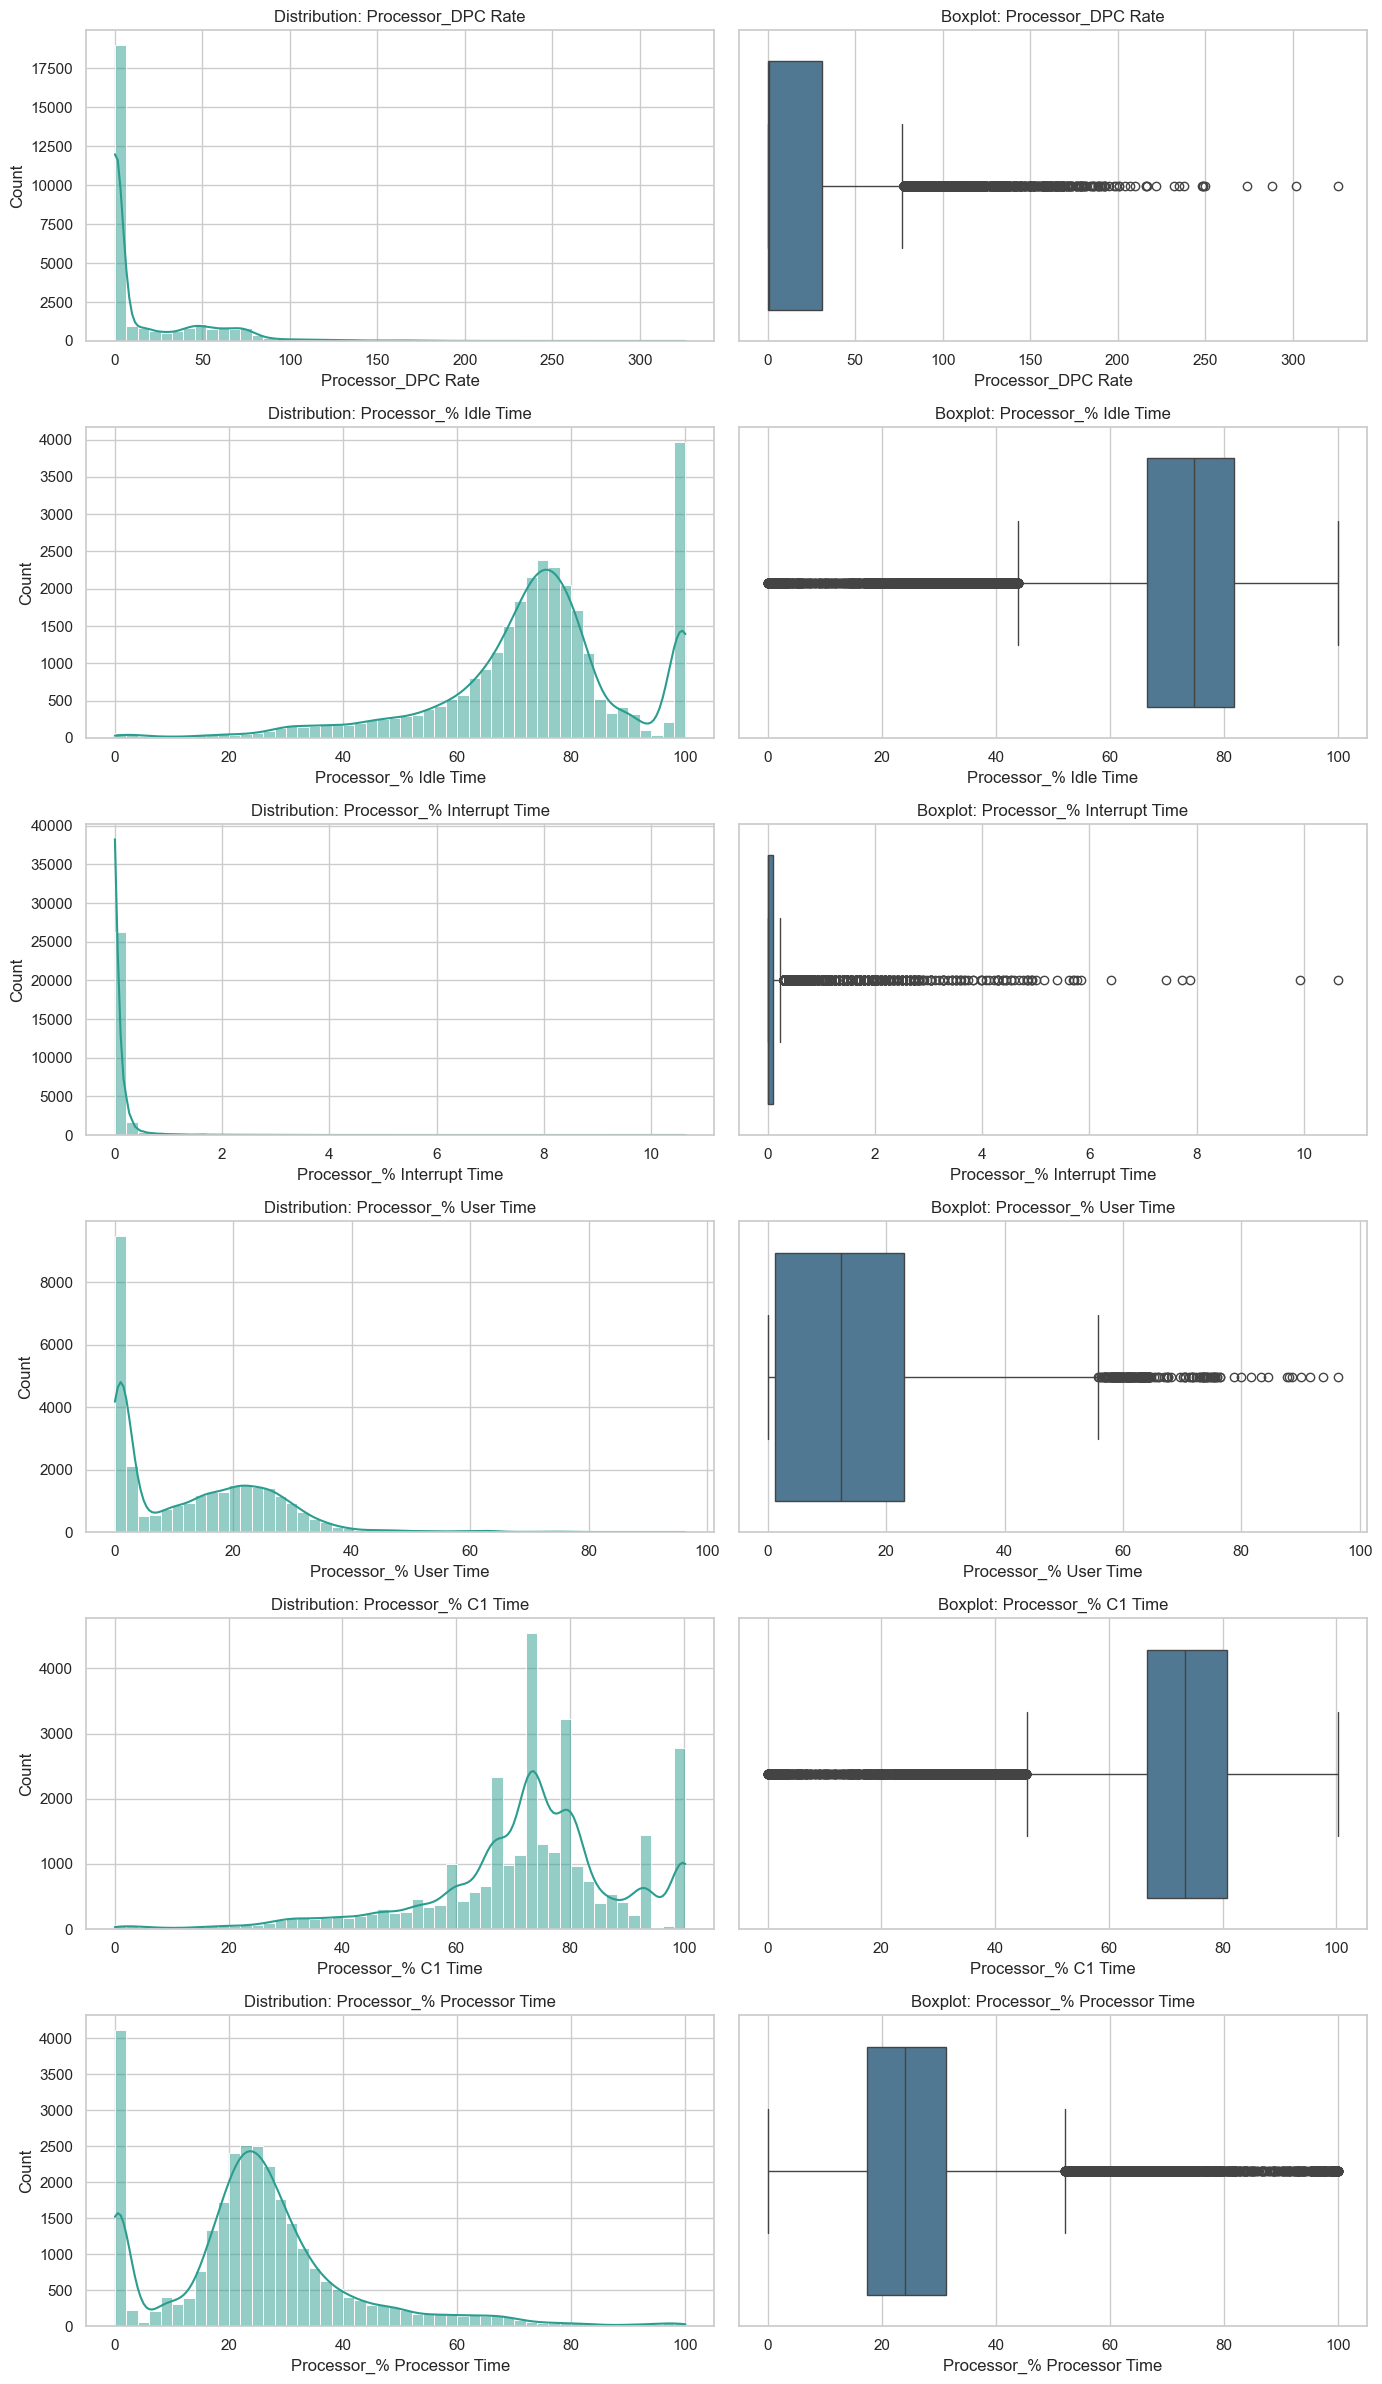

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {len(numeric_cols)}")

candidate_metrics = [
    "Processor(_Total)\\% Processor Time",
    "Memory\\Pages/sec",
    "Process(_Total)\\IO Data Bytes/sec",
    "Process(_Total)\\Page Faults/sec",
    "Memory\\% Committed Bytes In Use",
    "LogicalDisk(_Total)\\Disk Bytes/sec",
]

available_metrics = [c for c in candidate_metrics if c in df.columns]
if not available_metrics:
    available_metrics = numeric_cols[:6]

print("Selected metrics for univariate analysis:")
for c in available_metrics:
    print("-", c)

fig, axes = plt.subplots(len(available_metrics), 2, figsize=(14, 4 * len(available_metrics)))
if len(available_metrics) == 1:
    axes = np.array([axes])

for i, col in enumerate(available_metrics):
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i, 0], color="#2A9D8F")
    axes[i, 0].set_title(f"Distribution: {col}")

    sns.boxplot(x=df[col], ax=axes[i, 1], color="#457B9D")
    axes[i, 1].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

## 4) Grouped and Temporal Views

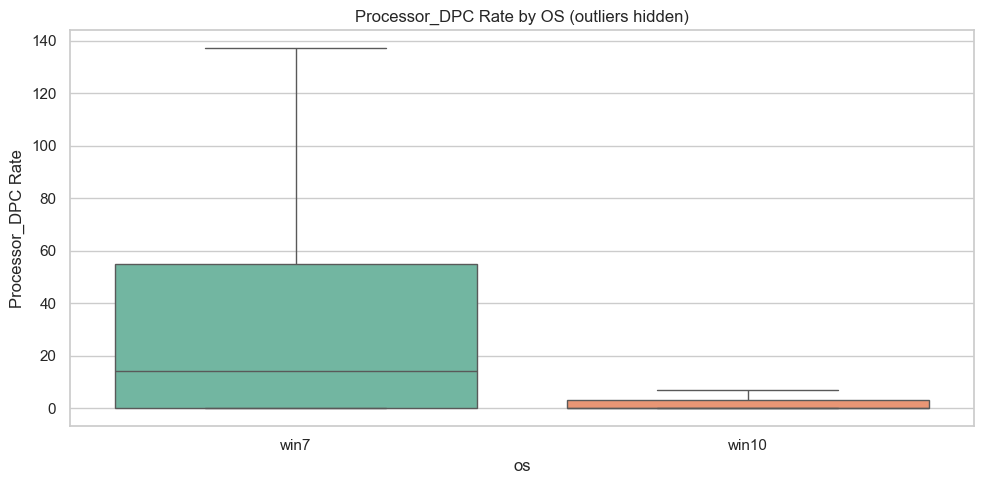

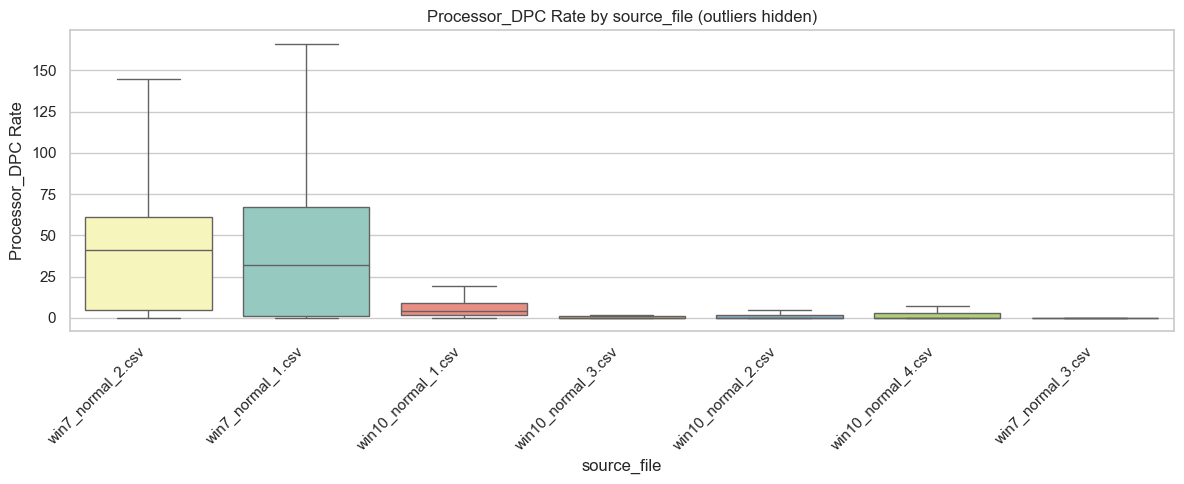

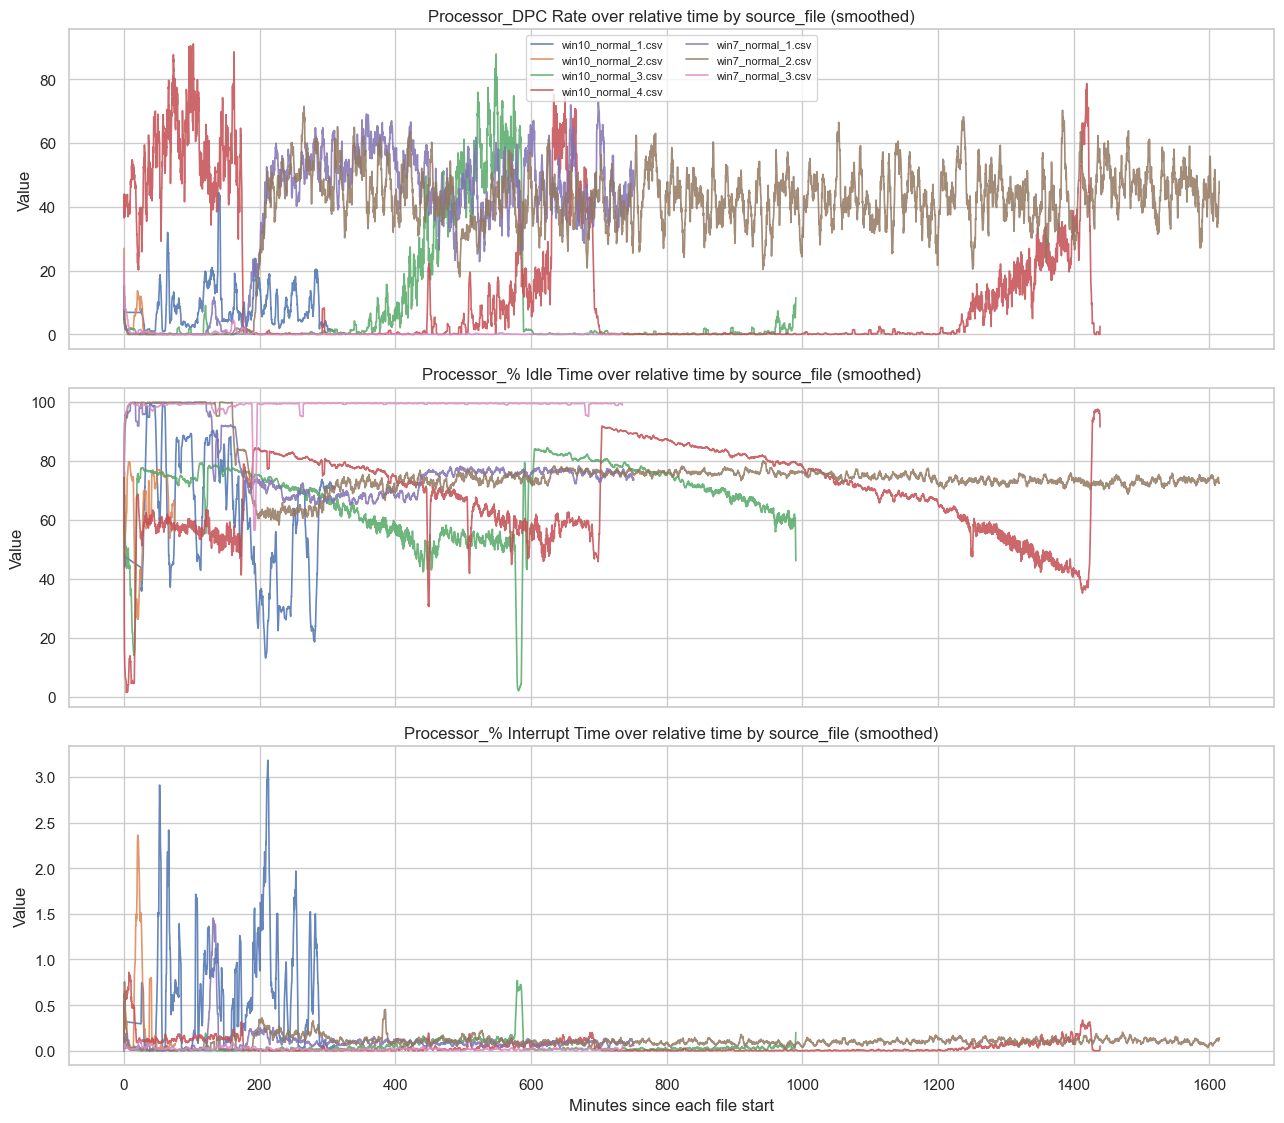

In [13]:
if "os" in df.columns and available_metrics:
    plot_col = available_metrics[0]
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=df,
        x="os",
        y=plot_col,
        hue="os",
        palette="Set2",
        showfliers=False,
        legend=False,
    )
    plt.title(f"{plot_col} by OS (outliers hidden)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

if "source_file" in df.columns and available_metrics:
    plot_col = available_metrics[0]
    order = (
        df.groupby("source_file", observed=False)[plot_col]
        .median()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=(12, 5))
    sns.boxplot(
        data=df,
        x="source_file",
        y=plot_col,
        hue="source_file",
        order=order,
        palette="Set3",
        showfliers=False,
        legend=False,
    )
    plt.title(f"{plot_col} by source_file (outliers hidden)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if "timestamp" in df.columns and available_metrics:
    ts_df = df.copy()
    ts_df["timestamp_parsed"] = pd.to_datetime(ts_df["timestamp"], errors="coerce")
    ts_df = ts_df.dropna(subset=["timestamp_parsed"]).sort_values("timestamp_parsed")

    if not ts_df.empty:
        metric_list = available_metrics[:3]
        n_rows = len(metric_list)
        fig, axes = plt.subplots(n_rows, 1, figsize=(13, 3.8 * n_rows), sharex=True)
        if n_rows == 1:
            axes = np.array([axes])

        if "source_file" in ts_df.columns:
            file_groups = ts_df.groupby("source_file", observed=False)
            for i, col in enumerate(metric_list):
                ax = axes[i]
                for source_name, g in file_groups:
                    s = (
                        g[["timestamp_parsed", col]]
                        .dropna()
                        .sort_values("timestamp_parsed")
                        .set_index("timestamp_parsed")[col]
                        .rolling(window=20, min_periods=1)
                        .mean()
                    )
                    if s.empty:
                        continue

                    minutes_since_start = (s.index - s.index.min()).total_seconds() / 60.0
                    ax.plot(minutes_since_start, s.values, linewidth=1.2, alpha=0.85, label=source_name)

                ax.set_title(f"{col} over relative time by source_file (smoothed)")
                ax.set_ylabel("Value")
                if i == 0:
                    ax.legend(fontsize=8, ncol=2)

            axes[-1].set_xlabel("Minutes since each file start")
        else:
            for i, col in enumerate(metric_list):
                ax = axes[i]
                s = (
                    ts_df[["timestamp_parsed", col]]
                    .dropna()
                    .set_index("timestamp_parsed")[col]
                    .resample("15min")
                    .median()
                    .rolling(window=3, min_periods=1)
                    .mean()
                )
                ax.plot(s.index, s.values, linewidth=1.4)
                ax.set_title(f"{col} over time (15-min median, smoothed)")
                ax.set_ylabel("Value")

            axes[-1].set_xlabel("Timestamp")

        plt.tight_layout()
        plt.show()

## 5) Correlation and Feature Relationships

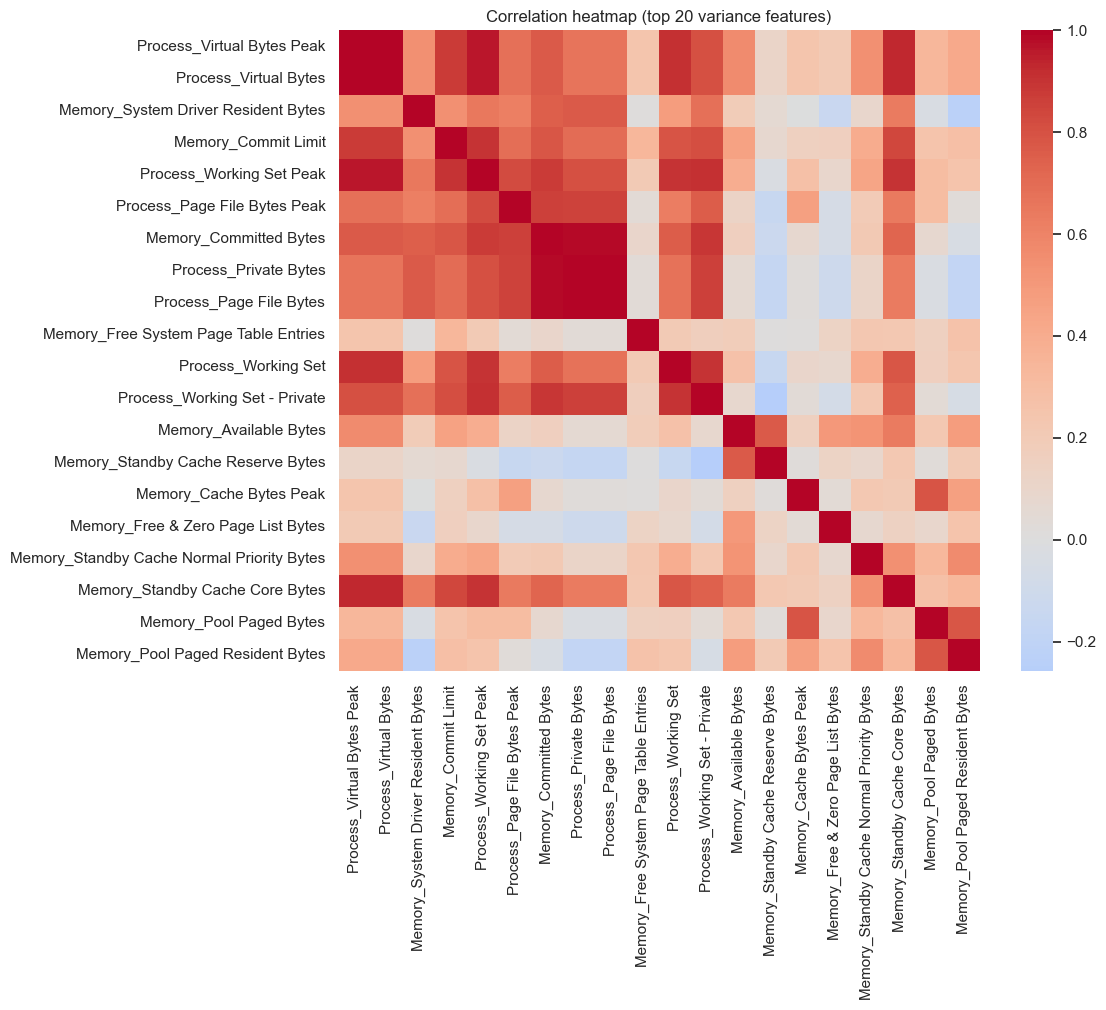

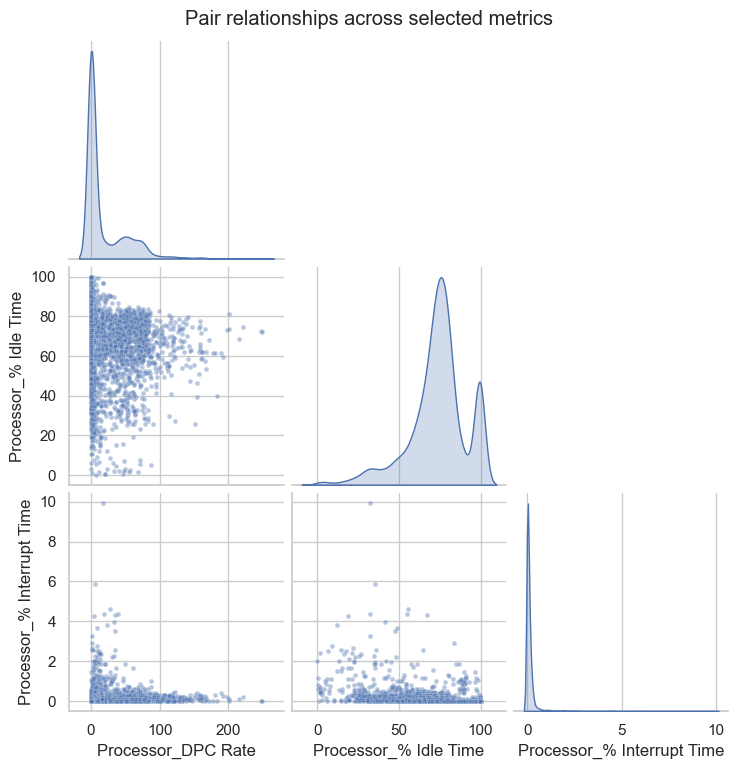

In [9]:
if numeric_cols:
    var_ranked = df[numeric_cols].var(numeric_only=True).sort_values(ascending=False)
    top_corr_cols = var_ranked.head(min(TOP_K_CORR_FEATURES, len(var_ranked))).index.tolist()

    corr = df[top_corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
    plt.title(f"Correlation heatmap (top {len(top_corr_cols)} variance features)")
    plt.tight_layout()
    plt.show()

if len(available_metrics) >= 3:
    scatter_df = df[available_metrics[:3]].dropna()
    if len(scatter_df) > MAX_SCATTER_POINTS:
        scatter_df = scatter_df.sample(MAX_SCATTER_POINTS, random_state=42)

    sns.pairplot(scatter_df, corner=True, diag_kind="kde", plot_kws={"alpha": 0.4, "s": 12})
    plt.suptitle("Pair relationships across selected metrics", y=1.02)
    plt.show()